# Proyek Klasifikasi Gambar: [Shoe vs Sandal vs Boot]
- **Nama:** [Juliani Leony Putri Melati Manalu]
- **Email:** [juliani.123140029@student.itera.ac.id]
- **ID Dicoding:** [CACC119D6X2207]

## Import Semua Packages/Library yang Digunakan

In [ ]:
!pip install tensorflowjs

In [ ]:
# Import library umum
import os
import random
import shutil
import zipfile
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# Image processing
from PIL import Image

# Machine learning & Data splitting
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Tensorflow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


## Data Preparation

### Data Loading

In [2]:
# Upload file kaggle.json
# Kaggle credential removed for security
from google.colab import files

files.upload()

{}

In [ ]:
# Download dataset
!kaggle datasets download -d hasibalmuzdadid/shoe-vs-sandal-vs-boot-dataset-15k-images

!unzip -q shoe-vs-sandal-vs-boot-dataset-15k-images.zip

print("Dataset berhasil di-download dan di-extract!")

Dataset URL: https://www.kaggle.com/datasets/hasibalmuzdadid/shoe-vs-sandal-vs-boot-dataset-15k-images
License(s): copyright-authors
100% 47.0M/47.0M [00:00<00:00, 95.0MB/s]

Dataset berhasil di-download dan di-extract!


### Data Preprocessing

#### Split Dataset

In [ ]:
# Path dataset asli
dataset_dir = '/content/Shoe vs Sandal vs Boot Dataset'

# Folder hasil split
base_dir = '/content/dataset_split'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Hapus folder lama jika ada
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Nama kelas
categories = ['Boot', 'Sandal', 'Shoe']

# Membuat folder train, val, dan test
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

    for category in categories:
        os.makedirs(os.path.join(folder, category), exist_ok=True)

# Split dataset
for category in categories:

    source_path = os.path.join(dataset_dir, category)

    image_files = [
        file for file in os.listdir(source_path)
        if file.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Acak data
    random.shuffle(image_files)

    # Split train 70% dan sisa 30%
    train_files, temp_files = train_test_split(
        image_files,
        test_size=0.3,
        random_state=42
    )

    # Split validation dan test
    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.5,
        random_state=42
    )

    # Copy train
    for file in train_files:
        shutil.copy(
            os.path.join(source_path, file),
            os.path.join(train_dir, category, file)
        )

    # Copy validation
    for file in val_files:
        shutil.copy(
            os.path.join(source_path, file),
            os.path.join(val_dir, category, file)
        )

    # Copy test
    for file in test_files:
        shutil.copy(
            os.path.join(source_path, file),
            os.path.join(test_dir, category, file)
        )

print("Dataset berhasil dibagi!")

Dataset berhasil dibagi!


Load Data dan Data Augmentation dengan ImageDataGenerator

In [ ]:
# Data augmentation untuk training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Validation dan test tanpa augmentasi
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 10500 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.


Menampilkan Sampel Gambar dari Setiap Kelas

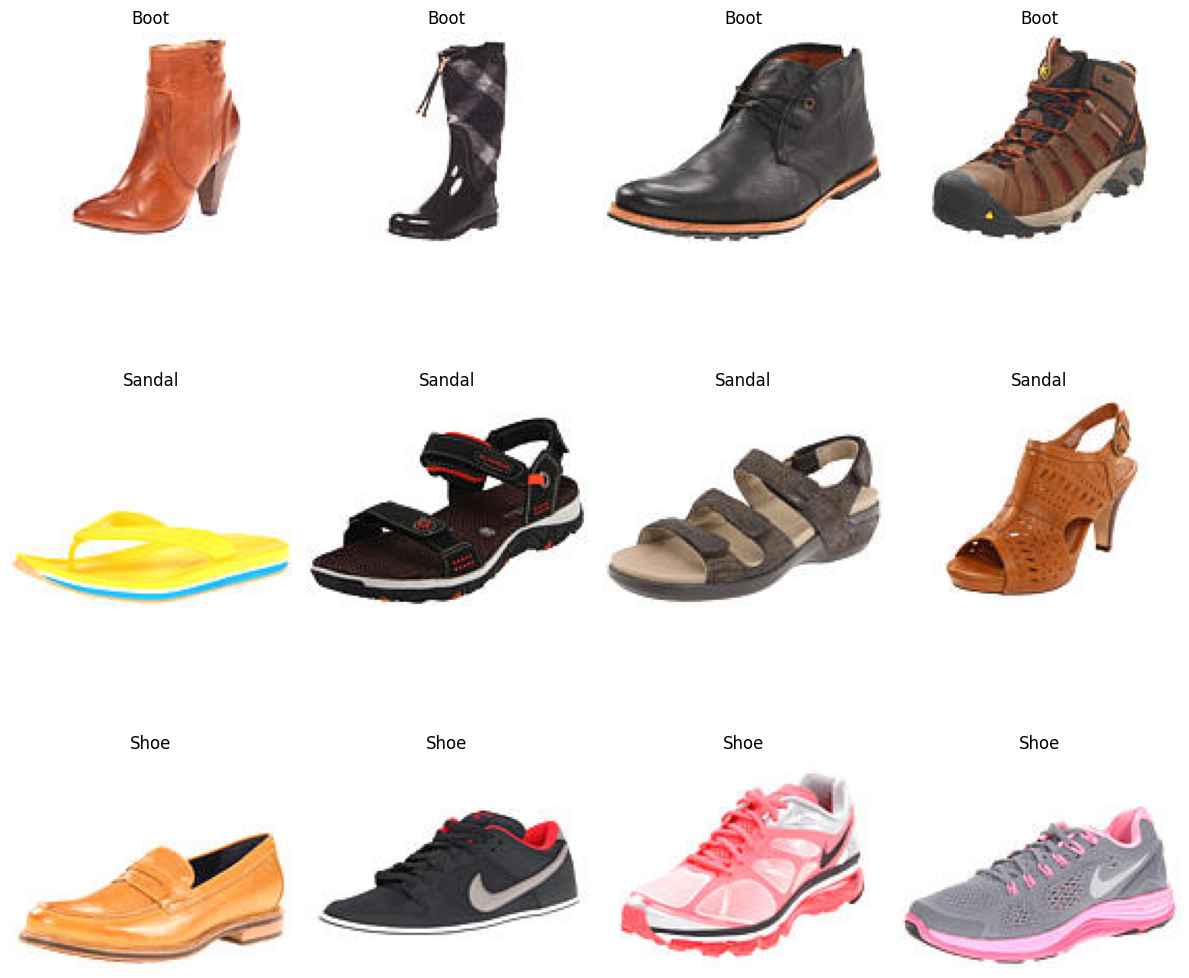

In [ ]:
# Menampilkan beberapa gambar dari setiap kelas
plt.figure(figsize=(12,12))

plot_index = 1

for class_name in categories:
    class_path = os.path.join(train_dir, class_name)

    # Ambil file gambar saja
    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Ambil maksimal 4 gambar
    sample_images = image_files[:4]
    for image_name in sample_images:
        image_path = os.path.join(class_path, image_name)
        img = mpimg.imread(image_path)

        plt.subplot(3, 4, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
        plot_index += 1

plt.tight_layout()
plt.show()

Visualisasi Distribusi Dataset

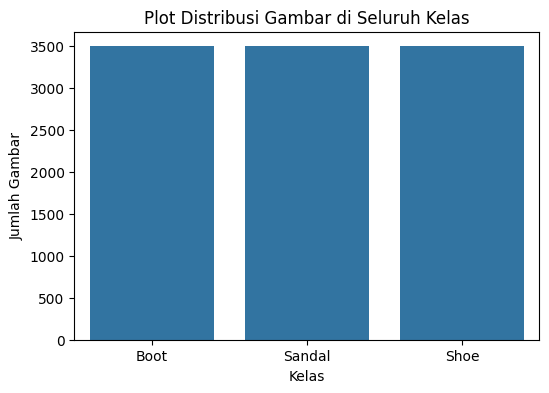

In [ ]:
# Menghitung jumlah gambar tiap kelas pada train set
train_count = []

for category in categories:
    total = len(os.listdir(os.path.join(train_dir, category)))
    train_count.append(total)

# Plot distribusi gambar di seluruh kelas
plt.figure(figsize=(6,4))

sns.barplot(
    x=categories,
    y=train_count
)

plt.title('Plot Distribusi Gambar di Seluruh Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')

plt.show()

## Modelling

Membangun Arsitektur CNN Model

In [ ]:
# Membangun model CNN

model = Sequential()

# Block 1
model.add(Input(shape=(150,150,3)))

model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 4
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Global Pooling
model.add(GlobalAveragePooling2D())

# Fully Connected
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output
model.add(Dense(3, activation='softmax'))

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,683 (1.65 MB)

 Trainable params: 430,723 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)

Callback

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.000001,
    verbose=1
)

callbacks = [early_stop, checkpoint, reduce_lr]

In [ ]:
# Mengambil label train
labels = train_generator.classes

# Menghitung class weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Mengubah menjadi dictionary
class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


Training Model

In [ ]:
# Training model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5486 - loss: 0.9470
Epoch 1: val_loss improved from None to 1.54789, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 1106s 3s/step - accuracy: 0.6078 - loss: 0.8617 - val_accuracy: 0.3449 - val_loss: 1.5479 - learning_rate: 1.0000e-04
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6964 - loss: 0.7087
Epoch 2: val_loss did not improve from 1.54789
329/329 ━━━━━━━━━━━━━━━━━━━━ 1112s 3s/step - accuracy: 0.7093 - loss: 0.6860 - val_accuracy: 0.7876 - val_loss: 0.4926 - learning_rate: 1.0000e-04
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7362 - loss: 0.6250
Epoch 3: val_loss did not improve from 1.54789
329/329 ━━━━━━━━━━━━━━━━━━━━ 1109s 3s/step - accuracy: 0.7438 - loss: 0.6136 - val_accuracy: 0.8307 - val_loss: 0.4300 - learning_rate: 1.0000e-04
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7773 - loss

## Evaluasi dan Visualisasi

Visualisasi Accuracy dan Loss Model

In [ ]:
# Evaluasi model pada test set
test_loss, test_accuracy = model.evaluate(test_generator)

print(f'Test Accuracy : {test_accuracy:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

# Visualisasi akurasi model
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Visualisasi loss model
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Confusion Matrix

In [ ]:
# Prediksi data test
predictions = model.predict(test_generator)

# Mengambil label prediksi
y_pred = np.argmax(predictions, axis=1)

# Label asli
y_true = test_generator.classes

# Membuat confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualisasi confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=categories,
    yticklabels=categories
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

## Konversi Model

Menyimpan Model ke Format SavedModel

In [ ]:
# Menyimpan model ke format SavedModel
model.export('saved_model')

print("Model SavedModel berhasil disimpan!")

Konversi Model ke Format TensorFlow Lite (TFLite)

In [ ]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model')

tflite_model = converter.convert()

# Menyimpan file .tflite
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model TFLite berhasil disimpan!")

Membuat File Label Kelas

In [ ]:
# Membuat file label
labels = ['Shoe', 'Sandal', 'Boot']

with open('label.txt', 'w') as f:
    for label in labels:
        f.write(label + '\n')

print("Label berhasil disimpan!")

Konversi Model ke Format TensorFlow.js (TFJS)

In [ ]:
# Konversi model ke TensorFlow.js
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    saved_model \
    tfjs_model

print("Model TFJS berhasil disimpan!")

## Inference (Optional)

In [ ]:
f# Inference gambar Sandal
sandal_images = os.listdir(os.path.join(test_dir, 'Sandal'))

# Memilih acak gambar sandal
random_sandal_image = random.choice(sandal_images)

image_path = os.path.join(
    test_dir,
    'Sandal',
    random_sandal_image
)

img = load_img(image_path, target_size=(150,150))

plt.imshow(img)
plt.title(f'Actual : Sandal\nImage: {random_sandal_image}')
plt.axis('off')

# Preprocessing
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = categories[predicted_index]

print(f"Predicted Class : {predicted_class}")
print("Prediction Probabilities:")
for i, prob in enumerate(prediction[0]):
    print(f"  {categories[i]}: {prob:.4f}")

In [ ]:
# Inference gambar Shoe
shoe_images = os.listdir(os.path.join(test_dir, 'Shoe'))

# Memilih acak gambar sepatu
random_shoe_image = random.choice(shoe_images)

image_path = os.path.join(
    test_dir,
    'Shoe',
    random_shoe_image
)

img = load_img(image_path, target_size=(150,150))

plt.imshow(img)
plt.title(f'Actual : Shoe\nImage: {random_shoe_image}')
plt.axis('off')

# Preprocessing
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = categories[predicted_index]

print(f"Predicted Class : {predicted_class}")
print("Prediction Probabilities:")
for i, prob in enumerate(prediction[0]):
    print(f"  {categories[i]}: {prob:.4f}")

In [ ]:
# Inference gambar Boot
boot_images = os.listdir(os.path.join(test_dir, 'Boot'))

# Memilih acak gambar boot
random_boot_image = random.choice(boot_images)

image_path = os.path.join(
    test_dir,
    'Boot',
    random_boot_image
)

img = load_img(image_path, target_size=(150,150))

plt.imshow(img)
plt.title(f'Actual : Boot\nImage: {random_boot_image}')
plt.axis('off')

# Preprocessing
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_class = categories[predicted_index]

print(f"Predicted Class : {predicted_class}")
print("Prediction Probabilities:")
for i, prob in enumerate(prediction[0]):
    print(f"  {categories[i]}: {prob:.4f}")

In [ ]:
pip freeze > requirements.txt